In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [2]:
df = pd.read_csv("../data_raw/date_24_art_loreal_20%.csv")
df = df[df["ID_ARTICOL"] == 147807]

df["DATA"] = pd.to_datetime(df["DATA"], errors="coerce")
df = df.sort_values(by=["DATA"]).reset_index(drop=True)


C:\Users\Mara\AppData\Local\Temp\ipykernel_24448\3689893565.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DATA"] = pd.to_datetime(df["DATA"], errors="coerce")


In [3]:
df_art = (
    df
    .set_index("DATA")["CANTITATE"]
    .asfreq("D")
)

df_art = df_art.interpolate("time").fillna(0)


In [4]:
forecast_horizon_daily = 14
n = len(df_art)
if forecast_horizon_daily >= n:
    raise ValueError("forecast_horizon_daily must be smaller than the series length")

split_idx = n - forecast_horizon_daily
train = df_art.iloc[:split_idx]
test = df_art.iloc[split_idx:]


ADF Statistic: -5.19372056626971
p-value: 9.055358716005692e-06


<Figure size 1000x400 with 0 Axes>

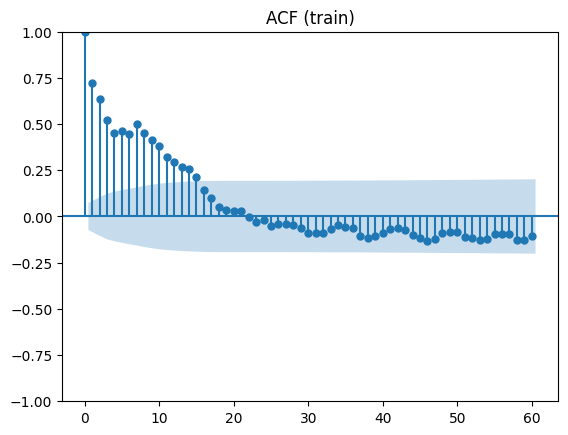

<Figure size 1000x400 with 0 Axes>

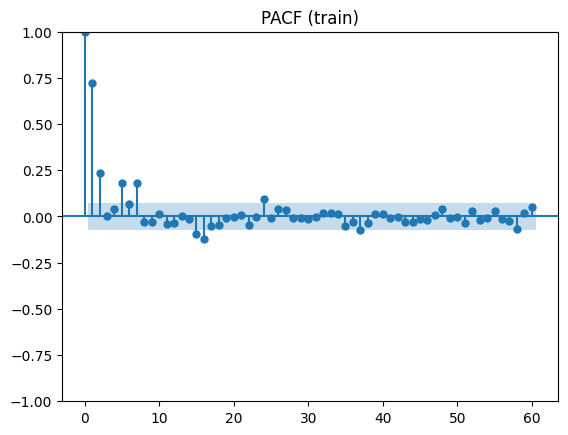

In [5]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ADF test
result = adfuller(train.dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

# ACF / PACF
plt.figure(figsize=(10,4))
plot_acf(train.dropna(), lags=60)
plt.title("ACF (train)")
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(train.dropna(), lags=60)
plt.title("PACF (train)")
plt.show()


In [6]:
sarima_weekly = auto_arima(
    train,
    seasonal=True,
    m=7,
    d=None,
    D=None,
    stepwise=True,
    suppress_warnings=True,
    trace=True
)


Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[7] intercept   : AIC=4665.449, Time=1.11 sec
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=5263.578, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=4693.095, Time=0.20 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=4877.874, Time=0.21 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=6007.511, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[7] intercept   : AIC=4672.033, Time=0.73 sec
 ARIMA(2,0,2)(1,0,0)[7] intercept   : AIC=4667.032, Time=0.77 sec
 ARIMA(2,0,2)(2,0,1)[7] intercept   : AIC=4667.435, Time=2.24 sec
 ARIMA(2,0,2)(1,0,2)[7] intercept   : AIC=4667.431, Time=2.42 sec
 ARIMA(2,0,2)(0,0,0)[7] intercept   : AIC=4697.281, Time=0.36 sec
 ARIMA(2,0,2)(0,0,2)[7] intercept   : AIC=4667.547, Time=1.49 sec
 ARIMA(2,0,2)(2,0,0)[7] intercept   : AIC=4665.663, Time=1.42 sec
 ARIMA(2,0,2)(2,0,2)[7] intercept   : AIC=4669.447, Time=2.30 sec
 ARIMA(1,0,2)(1,0,1)[7] intercept   : AIC=4664.639, Time=0.82 sec
 ARIMA(1,0,2)(0,0,1)[7] intercept

 ARIMA(2,0,2)(1,0,1)[30] intercept   : AIC=4698.771, Time=2.96 sec
 ARIMA(0,0,0)(0,0,0)[30] intercept   : AIC=5263.578, Time=0.01 sec


 ARIMA(1,0,0)(1,0,0)[30] intercept   : AIC=4733.142, Time=0.60 sec


 ARIMA(0,0,1)(0,0,1)[30] intercept   : AIC=4972.452, Time=0.55 sec
 ARIMA(0,0,0)(0,0,0)[30]             : AIC=6007.511, Time=0.01 sec


 ARIMA(2,0,2)(0,0,1)[30] intercept   : AIC=4697.107, Time=1.67 sec


...

 ARIMA(2,0,0)(0,0,1)[30] intercept   : AIC=4693.516, Time=0.74 sec


 ARIMA(2,0,0)(2,0,1)[30] intercept   : AIC=4696.201, Time=10.05 sec


 ARIMA(3,0,0)(1,0,0)[30] intercept   : AIC=4695.409, Time=1.35 sec


 ARIMA(3,0,1)(1,0,0)[30] intercept   : AIC=4697.409, Time=1.44 sec


 ARIMA(2,0,0)(1,0,0)[30]             : AIC=4733.663, Time=0.36 sec

Best model:  ARIMA(2,0,0)(1,0,0)[30] intercept
Total fit time: 117.201 seconds


In [9]:
pred = pd.Series(
    sarima_weekly.predict(n_periods=len(test)),
    index=test.index
)

mae = mean_absolute_error(test, pred)
rmse = np.sqrt(mean_squared_error(test, pred))

print("SARIMA | MAE:", mae)
print("SARIMA | RMSE:", rmse)


SARIMA | MAE: 5.709561047687777
SARIMA | RMSE: 6.571509611721651


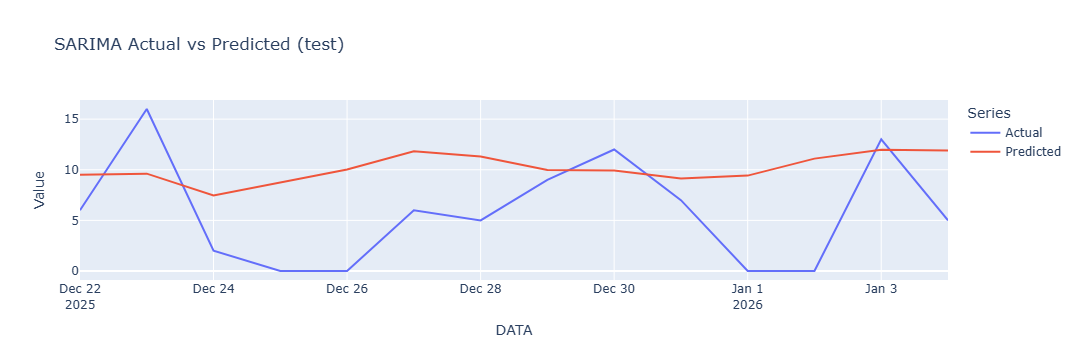

In [11]:
df_plot = pd.DataFrame({
    "DATA": test.index,
    "Actual": test.values,
    "Predicted": pred.values
})

df_long = df_plot.melt("DATA", var_name="Series", value_name="Value")

fig = px.line(
    df_long,
    x="DATA",
    y="Value",
    color="Series",
    title="SARIMA Actual vs Predicted (test)"
)
fig.show()
